In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 5)

DATA_DIR = "/kaggle/input/datasets/shreyaskeote23/india-economics-data"

In [2]:
files = sorted(os.listdir(DATA_DIR))
for f in files:
    print(f)

1 - India_Economic_Growth_Historical_Data.csv
10 - India_Manufacturing_Output_Historical_Data.csv
2 -India_GDP_Growth_Rate_Historical_Data.csv
4 - India_GDP_Per_Capita_Historical_Data.csv
5 - India_GNI_Historical_Data.csv
6 - India_GNI_Per_Capita_Historical_Data.csv
7 - India_GNP_Historical_Data.csv
8 - India_Government_Debt_as_percent_of_GDP_Historical_Data.csv
9 - India_Inflation_Rate_Historical_Data.csv


In [3]:
def find_file(prefix_number: int) -> str:
    """Match a file by its leading number, tolerant of inconsistent spacing in filenames."""
    for f in files:
        if re.match(rf"^{prefix_number}\s*-\s*", f):
            return os.path.join(DATA_DIR, f)
    raise FileNotFoundError(f"No file starting with '{prefix_number}'")

# Quick sanity check that every expected file resolves
for n in [1, 2, 4, 5, 6, 7, 8, 9, 10]:
    print(n, "->", os.path.basename(find_file(n)))


1 -> 1 - India_Economic_Growth_Historical_Data.csv
2 -> 2 -India_GDP_Growth_Rate_Historical_Data.csv
4 -> 4 - India_GDP_Per_Capita_Historical_Data.csv
5 -> 5 - India_GNI_Historical_Data.csv
6 -> 6 - India_GNI_Per_Capita_Historical_Data.csv
7 -> 7 - India_GNP_Historical_Data.csv
8 -> 8 - India_Government_Debt_as_percent_of_GDP_Historical_Data.csv
9 -> 9 - India_Inflation_Rate_Historical_Data.csv
10 -> 10 - India_Manufacturing_Output_Historical_Data.csv


In [4]:
inflation_raw = pd.read_csv(find_file(9))
inflation_raw.head()

,Unnamed: 0,year,Inflation_Rate,Annual_percent_geowth
0,0,2022,6.70%,1.57%
1,1,2021,5.13%,-1.49%
2,2,2020,6.62%,2.89%
3,3,2019,3.73%,-0.21%
4,4,2018,3.94%,0.61%


In [5]:
inflation_raw.tail()

,Unnamed: 0,year,Inflation_Rate,Annual_percent_geowth
58,58,1964,13.36%,10.41%
59,59,1963,2.95%,-0.69%
60,60,1962,3.63%,1.94%
61,61,1961,1.70%,-0.08%
62,62,1960,1.78%,-0.08%


In [6]:
print("Shape:", inflation_raw.shape)
inflation_raw.info()

Shape: (63, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Unnamed: 0             63 non-null     int64 
 1   year                   63 non-null     int64 
 2   Inflation_Rate         63 non-null     object
 3   Annual_percent_geowth  63 non-null     object
dtypes: int64(2), object(2)
memory usage: 2.1+ KB


In [7]:
inflation_raw.describe(include="all")

,Unnamed: 0,year,Inflation_Rate,Annual_percent_geowth
count,63.000000,63.000000,63,63
unique,NaN,NaN,63,61
top,NaN,NaN,6.70%,0.58%
freq,NaN,NaN,1,2
mean,31.000000,1991.000000,NaN,NaN
std,18.330303,18.330303,NaN,NaN
min,0.000000,1960.000000,NaN,NaN
25%,15.500000,1975.500000,NaN,NaN
50%,31.000000,1991.000000,NaN,NaN
75%,46.500000,2006.500000,NaN,NaN


In [8]:
inflation_raw.columns

Index(['Unnamed: 0', 'year', 'Inflation_Rate', 'Annual_percent_geowth'], dtype='object')

In [9]:
inflation_raw.isna().sum()

Unnamed: 0               0
year                     0
Inflation_Rate           0
Annual_percent_geowth    0
dtype: int64

In [10]:
# Every file has an unnamed pandas-index column left over from however
# this was originally exported — confirm it's just a row counter, not data
(inflation_raw["Unnamed: 0"] == inflation_raw.index).all()

np.True_

In [11]:
def parse_percent(series: pd.Series) -> pd.Series:
    """'7.24%' -> 7.24"""
    return series.astype(str).str.rstrip("%").astype(float)

def parse_money(series: pd.Series) -> pd.Series:
    """'$3,416.65B' -> 3416.65 (billions, as float); also handles 'M'/'T' suffixes and plain numbers."""
    suffix_multiplier = {"T": 1000, "B": 1, "M": 0.001, "K": 0.000001}

    def _parse_one(val: str) -> float:
        val = val.strip().lstrip("$").replace(",", "")
        suffix = val[-1] if val[-1].isalpha() else None
        if suffix in suffix_multiplier:
            return float(val[:-1]) * suffix_multiplier[suffix]
        return float(val)

    return series.astype(str).apply(_parse_one)

# Quick check on inflation (percent only, no currency parsing needed here)
parse_percent(inflation_raw["Inflation_Rate"]).head()

0    6.70
1    5.13
2    6.62
3    3.73
4    3.94
Name: Inflation_Rate, dtype: float64

In [12]:
gdp_growth_raw = pd.read_csv(find_file(2))
gdp_growth_raw.columns = ["idx", "year", "gdp_growth_pct", "gdp_growth_annual_change_pct"]
gdp_growth_raw["gdp_growth_pct"] = parse_percent(gdp_growth_raw["gdp_growth_pct"])
gdp_growth_raw["gdp_growth_annual_change_pct"] = parse_percent(gdp_growth_raw["gdp_growth_annual_change_pct"])
gdp_growth = gdp_growth_raw.set_index("year")[["gdp_growth_pct"]].sort_index()
gdp_growth.head()

,gdp_growth_pct
year,
1960,0.00
1961,3.72
1962,2.93
1963,5.99
1964,7.45


In [13]:
inflation_clean = inflation_raw.copy()
inflation_clean.columns = ["idx", "year", "inflation_pct", "inflation_annual_change_pct"]
inflation_clean["inflation_pct"] = parse_percent(inflation_clean["inflation_pct"])
inflation = inflation_clean.set_index("year")[["inflation_pct"]].sort_index()
inflation.head()

,inflation_pct
year,
1960,1.78
1961,1.70
1962,3.63
1963,2.95
1964,13.36


In [14]:
debt_raw = pd.read_csv(find_file(8))
debt_raw.columns = ["idx", "year", "govt_debt_pct_gdp", "govt_debt_annual_change_pct"]
debt_raw["govt_debt_pct_gdp"] = parse_percent(debt_raw["govt_debt_pct_gdp"])
debt = debt_raw.set_index("year")[["govt_debt_pct_gdp"]].sort_index()
debt.head()

,govt_debt_pct_gdp
year,
1960,0.0
1961,0.0
1962,0.0
1963,0.0
1964,0.0


In [15]:
# Data quality check: this column is reported as a flat 0.00% for over half
# the dataset's history. Worth knowing before drawing any conclusions from it.
zero_share = (debt["govt_debt_pct_gdp"] == 0).mean()
print(f"Share of years with govt_debt_pct_gdp == 0.00%: {zero_share:.1%}")
debt["govt_debt_pct_gdp"].value_counts().head()

Share of years with govt_debt_pct_gdp == 0.00%: 54.0%


govt_debt_pct_gdp
0.00     34
50.78     1
50.01     1
49.68     1
51.76     1
Name: count, dtype: int64

In [16]:
macro = gdp_growth.join(inflation, how="inner").join(debt, how="inner")
macro.head()

,gdp_growth_pct,inflation_pct,govt_debt_pct_gdp
year,,,
1960,0.00,1.78,0.0
1961,3.72,1.70,0.0
1962,2.93,3.63,0.0
1963,5.99,2.95,0.0
1964,7.45,13.36,0.0


In [17]:
macro.tail()

,gdp_growth_pct,inflation_pct,govt_debt_pct_gdp
year,,,
2018,6.45,3.94,46.52
2019,3.87,3.73,0.00
2020,-5.83,6.62,0.00
2021,9.05,5.13,0.00
2022,7.24,6.70,0.00


In [18]:
print("Shape:", macro.shape)
macro.describe()

Shape: (63, 3)


,gdp_growth_pct,inflation_pct,govt_debt_pct_gdp
count,63.000000,63.000000,63.000000
mean,5.058571,7.365714,24.382540
std,3.262885,4.869070,26.840888
min,-5.830000,-7.630000,0.000000
25%,3.760000,4.130000,0.000000
50%,5.710000,6.670000,0.000000
75%,7.500000,9.750000,50.525000
max,9.630000,28.600000,62.590000


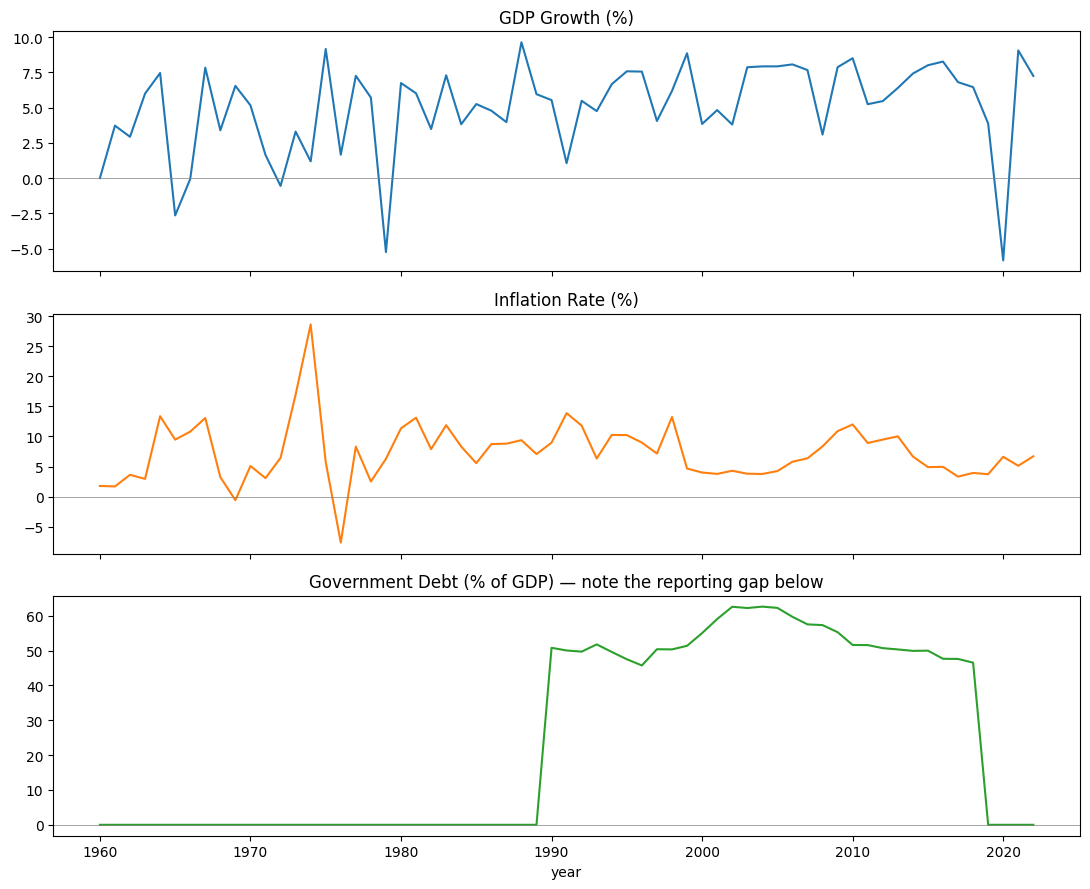

In [19]:
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 9))
macro["gdp_growth_pct"].plot(ax=axes[0], title="GDP Growth (%)", color="tab:blue")
macro["inflation_pct"].plot(ax=axes[1], title="Inflation Rate (%)", color="tab:orange")
macro["govt_debt_pct_gdp"].plot(ax=axes[2], title="Government Debt (% of GDP) — note the reporting gap below", color="tab:green")
for ax in axes:
    ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

In [20]:
def flag_regime_shifts(series: pd.Series, window: int = 8, z_threshold: float = 1.5) -> pd.DataFrame:
    changes = series.diff()
    roll_mean = changes.rolling(window, min_periods=3).mean()
    roll_std = changes.rolling(window, min_periods=3).std()
    z = (changes - roll_mean) / roll_std

    out = pd.DataFrame({"value": series, "change": changes, "z_score": z})
    out["flag"] = out["z_score"].abs() >= z_threshold
    return out

inflation_shifts = flag_regime_shifts(macro["inflation_pct"])
inflation_shifts[inflation_shifts["flag"]]

,value,change,z_score,flag
year,,,,
1968,3.24,-9.82,-1.742206,True
1973,16.94,10.50,1.544164,True
1975,5.75,-22.85,-1.913294,True
1991,13.87,4.90,1.549184,True
1993,6.33,-5.46,-1.670828,True
1999,4.67,-8.56,-1.580362,True
2008,8.35,1.98,1.685976,True
2009,10.88,2.53,1.587870,True
2011,8.91,-3.08,-2.159297,True


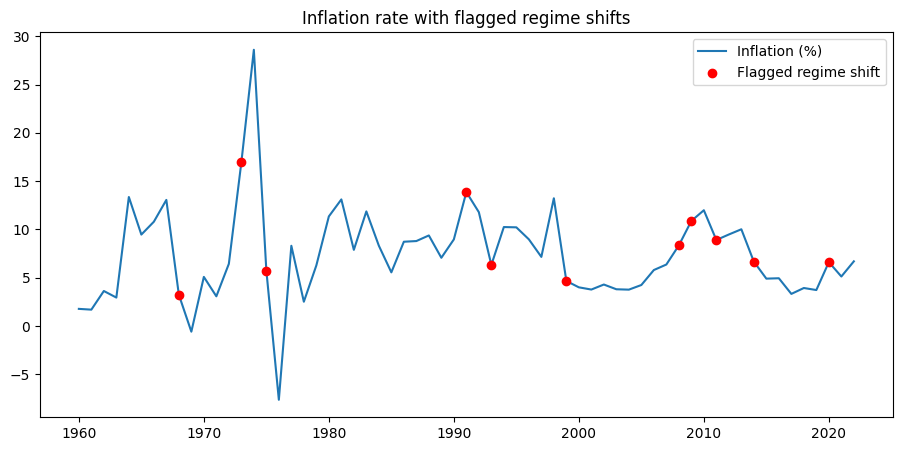

In [21]:
fig, ax = plt.subplots()
ax.plot(macro.index, macro["inflation_pct"], label="Inflation (%)")
flagged = inflation_shifts[inflation_shifts["flag"]]
ax.scatter(flagged.index, macro.loc[flagged.index, "inflation_pct"], color="red", zorder=5, label="Flagged regime shift")
ax.legend()
ax.set_title("Inflation rate with flagged regime shifts")
plt.show()

In [22]:
growth_shifts = flag_regime_shifts(macro["gdp_growth_pct"])
growth_shifts[growth_shifts["flag"]]

,value,change,z_score,flag
year,,,,
1965,-2.64,-10.09,-1.701193,True
1975,9.15,7.96,1.800896,True
1979,-5.24,-10.95,-1.564555,True
1988,9.63,5.66,1.707571,True
2000,3.84,-5.01,-1.734998,True
2008,3.09,-4.57,-1.884789,True
2019,3.87,-2.58,-1.917574,True
2020,-5.83,-9.70,-2.319515,True
2021,9.05,14.88,2.135033,True


In [23]:
macro[["gdp_growth_pct", "inflation_pct"]].corr()

,gdp_growth_pct,inflation_pct
gdp_growth_pct,1.000000,-0.003164
inflation_pct,-0.003164,1.000000


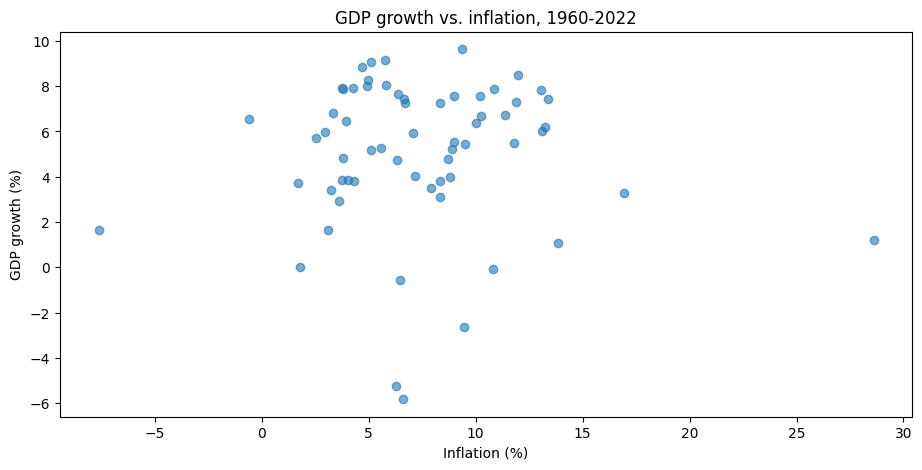

In [24]:
fig, ax = plt.subplots()
ax.scatter(macro["inflation_pct"], macro["gdp_growth_pct"], alpha=0.6)
ax.set_xlabel("Inflation (%)")
ax.set_ylabel("GDP growth (%)")
ax.set_title("GDP growth vs. inflation, 1960-2022")
plt.show()